# Phase 4 — Risk Model Evaluation Report

**Model A:** Visit Risk Classification (Low / Medium / High)  
**Artifact:** `Phase3_Modeling/models/risk_model.joblib`  
**Evaluator:** Phase 4 — independent evaluation notebook

---
| Section | Content |
|---------|--------|
| 1 | Setup & data reload |
| 2 | Train vs Test performance (overfitting check) |
| 3 | Confusion matrix & per-class metrics |
| 4 | Business metric — High-Risk recall |
| 5 | Feature importance & SHAP explainability |
| 6 | Fairness segmentation (gender, city, insurer) |
| 7 | Diagnosis & recommendations |

In [1]:
import warnings, json, joblib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score,
    f1_score, precision_score, recall_score
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

MODELS_DIR = Path('../Phase3_Modeling/models')
SCHEMA_PATH = Path('../Phase3_Modeling/feature_schema.json')
OUT_DIR = Path('.')

with open(SCHEMA_PATH) as f:
    schema = json.load(f)

rs = schema['risk_model']
print('Schema loaded. Features:', len(rs['all_features']))

Schema loaded. Features: 13


## 1. Data Reload & Feature Reconstruction

In [2]:
df = pd.read_csv(
    '../Phase2_EDA/model_table.csv',
    parse_dates=['visit_date', 'billing_date', 'registration_date']
)
df = df.sort_values('visit_date').reset_index(drop=True)

# Rebuild encoded categoricals
for col in rs['categorical_features']:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))

risk_le = joblib.load(MODELS_DIR / 'risk_label_encoder.joblib')
df['risk_label'] = risk_le.transform(df['risk_score'])

X = df[rs['all_features']]
y = df['risk_label']

split_idx = int(len(df) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
meta_test = df[['visit_date', 'gender', 'city', 'insurance_provider', 'risk_score']].iloc[split_idx:].reset_index(drop=True)

model = joblib.load(MODELS_DIR / 'risk_model.joblib')
CLASSES = list(risk_le.classes_)   # ['High', 'Low', 'Medium']

y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

print(f'Train rows: {len(X_train):,}   Test rows: {len(X_test):,}')
print('Classes:', CLASSES)

Train rows: 20,000   Test rows: 5,000
Classes: ['High', 'Low', 'Medium']


## 2. Train vs Test Performance — Overfitting Check

       Accuracy  F1-Macro  F1-Weighted  Precision-Macro  Recall-Macro
Split                                                                
Train    0.6975    0.6795       0.6937           0.7018        0.6662
Test     0.4034    0.3409       0.3953           0.3427        0.3452

Overfitting gap (Train - Test):
Accuracy           0.2941
F1-Macro           0.3386
F1-Weighted        0.2984
Precision-Macro    0.3591
Recall-Macro       0.3210


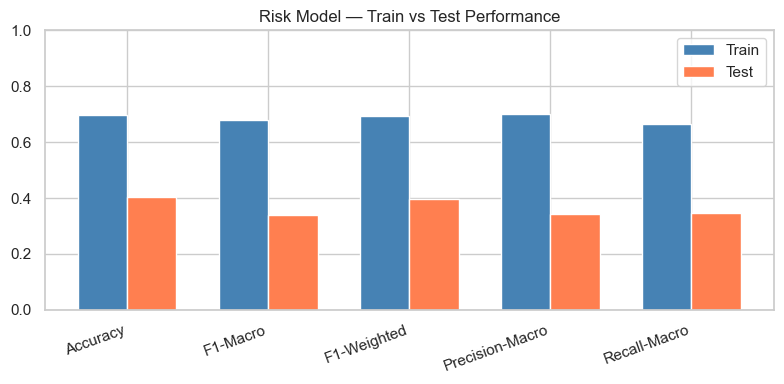


⚠ Large Train-Test gap indicates overfitting — addressed in Section 7.


In [3]:
metrics = {
    'Split':        ['Train', 'Test'],
    'Accuracy':     [accuracy_score(y_train, y_train_pred), accuracy_score(y_test, y_test_pred)],
    'F1-Macro':     [f1_score(y_train, y_train_pred, average='macro'), f1_score(y_test, y_test_pred, average='macro')],
    'F1-Weighted':  [f1_score(y_train, y_train_pred, average='weighted'), f1_score(y_test, y_test_pred, average='weighted')],
    'Precision-Macro': [precision_score(y_train, y_train_pred, average='macro'), precision_score(y_test, y_test_pred, average='macro')],
    'Recall-Macro': [recall_score(y_train, y_train_pred, average='macro'), recall_score(y_test, y_test_pred, average='macro')],
}
perf_df = pd.DataFrame(metrics).set_index('Split').round(4)
print(perf_df.to_string())

overfit_gap = perf_df.loc['Train'] - perf_df.loc['Test']
print('\nOverfitting gap (Train - Test):')
print(overfit_gap.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(perf_df.columns))
w = 0.35
ax.bar(x - w/2, perf_df.loc['Train'], w, label='Train', color='steelblue')
ax.bar(x + w/2, perf_df.loc['Test'],  w, label='Test',  color='coral')
ax.set_xticks(x)
ax.set_xticklabels(perf_df.columns, rotation=20, ha='right')
ax.set_ylim(0, 1)
ax.set_title('Risk Model — Train vs Test Performance')
ax.legend()
plt.tight_layout()
plt.savefig('risk_train_vs_test.png', dpi=120)
plt.show()

print('\n⚠ Large Train-Test gap indicates overfitting — addressed in Section 7.')

## 3. Confusion Matrix & Per-Class Metrics

=== Test Set Classification Report ===
              precision    recall  f1-score   support

        High       0.19      0.13      0.15      1023
         Low       0.52      0.54      0.53      2480
      Medium       0.32      0.37      0.34      1497

    accuracy                           0.40      5000
   macro avg       0.34      0.35      0.34      5000
weighted avg       0.39      0.40      0.40      5000



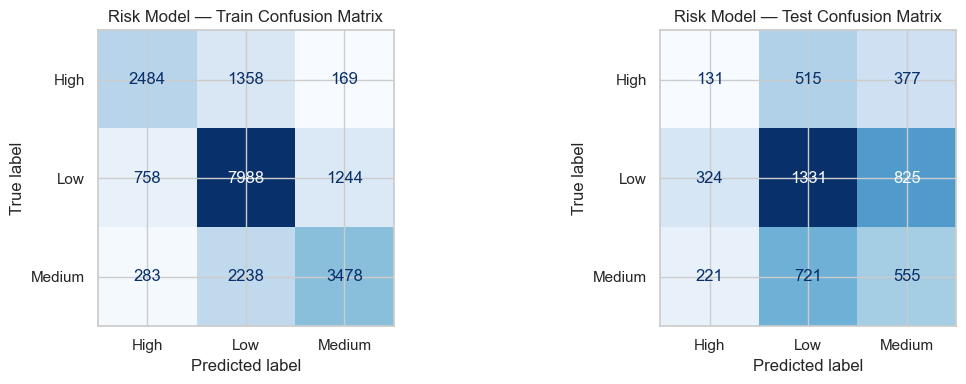

In [4]:
print('=== Test Set Classification Report ===')
print(classification_report(y_test, y_test_pred, target_names=CLASSES))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, preds, split in zip(axes, [y_train_pred, y_test_pred], ['Train', 'Test']):
    y_true = y_train if split == 'Train' else y_test
    ConfusionMatrixDisplay.from_predictions(
        y_true, preds, display_labels=CLASSES,
        cmap='Blues', ax=ax, colorbar=False
    )
    ax.set_title(f'Risk Model — {split} Confusion Matrix')
plt.tight_layout()
plt.savefig('risk_confusion_matrices.png', dpi=120)
plt.show()

## 4. Business Metric — High-Risk Recall

> **Clinical imperative:** A missed High-Risk patient (False Negative) has direct patient safety consequences.  
> **Target:** High-Risk recall ≥ 0.70 for production deployment.

        precision  recall  f1-score  support
High       0.1938  0.1281    0.1542     1023
Low        0.5185  0.5367    0.5274     2480
Medium     0.3159  0.3707    0.3411     1497

High-Risk Recall : 0.1281  |  Target: 0.7  |  ❌ BELOW TARGET


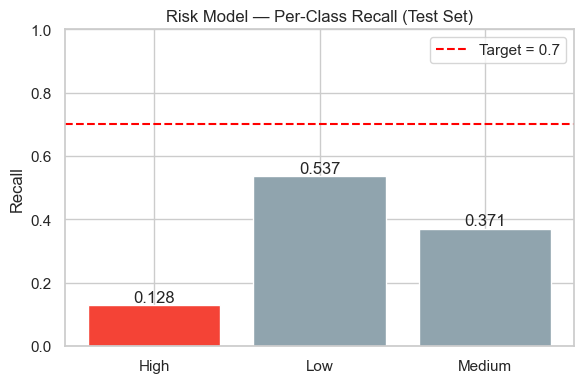

In [5]:
hi_idx = CLASSES.index('High')

report_dict = classification_report(y_test, y_test_pred, target_names=CLASSES, output_dict=True)
per_class = pd.DataFrame(report_dict).T.loc[CLASSES, ['precision', 'recall', 'f1-score', 'support']]
per_class['support'] = per_class['support'].astype(int)
per_class = per_class.round(4)
print(per_class.to_string())

high_recall = per_class.loc['High', 'recall']
TARGET_RECALL = 0.70
status = '✅ PASS' if high_recall >= TARGET_RECALL else '❌ BELOW TARGET'
print(f'\nHigh-Risk Recall : {high_recall:.4f}  |  Target: {TARGET_RECALL}  |  {status}')

colors = ['#F44336' if c == 'High' else '#90A4AE' for c in CLASSES]
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(CLASSES, per_class['recall'].values, color=colors)
ax.axhline(TARGET_RECALL, color='red', linestyle='--', label=f'Target = {TARGET_RECALL}')
for bar, v in zip(bars, per_class['recall'].values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{v:.3f}', ha='center')
ax.set_ylim(0, 1)
ax.set_title('Risk Model — Per-Class Recall (Test Set)')
ax.set_ylabel('Recall')
ax.legend()
plt.tight_layout()
plt.savefig('risk_recall_by_class.png', dpi=120)
plt.show()

## 5. Feature Importance & Explainability

Top 10 features:
length_of_stay_hours       0.2025
avg_los_per_patient        0.1628
days_since_registration    0.1539
age                        0.1310
visit_frequency            0.0815
visit_month                0.0671
department_enc             0.0445
dept_avg_billed            0.0429
visit_type_enc             0.0373
visit_quarter              0.0278


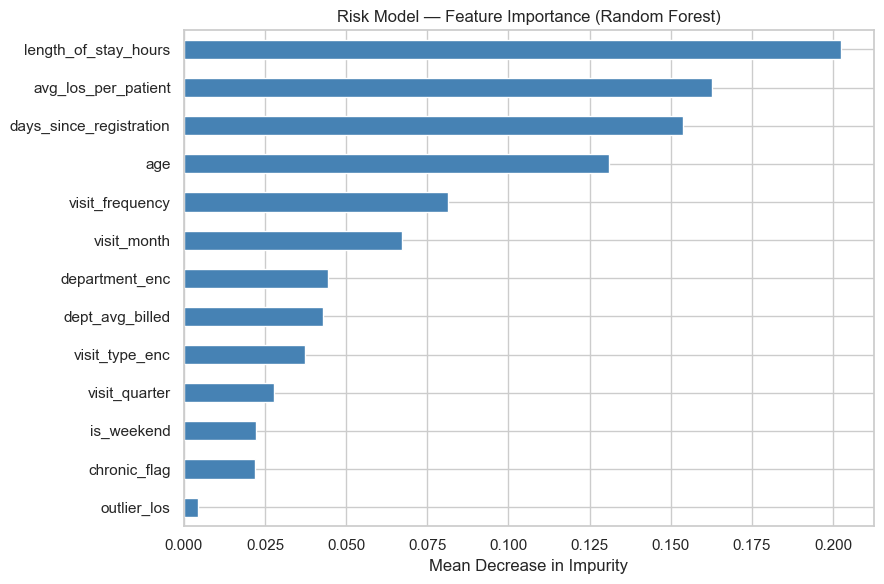

In [6]:
feat_imp = pd.Series(model.feature_importances_, index=rs['all_features']).sort_values(ascending=False)

print('Top 10 features:')
print(feat_imp.head(10).round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 6))
feat_imp.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Risk Model — Feature Importance (Random Forest)')
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.savefig('risk_feature_importance.png', dpi=120)
plt.show()

In [7]:
# SHAP explainability on a sample
try:
    import shap
    sample = X_test.sample(500, random_state=42)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(sample)

    # Summary plot for High-Risk class
    fig, ax = plt.subplots(figsize=(9, 6))
    shap.summary_plot(
        shap_values[hi_idx], sample,
        feature_names=rs['all_features'],
        plot_type='bar', show=False
    )
    plt.title('SHAP Feature Impact — High-Risk Class')
    plt.tight_layout()
    plt.savefig('risk_shap_high.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('SHAP summary saved.')
except ImportError:
    print('shap not installed — skipping SHAP plots.')
    print('Install with: pip install shap')
    print('Feature importance chart above serves as the explainability proxy.')

shap not installed — skipping SHAP plots.
Install with: pip install shap
Feature importance chart above serves as the explainability proxy.


### Explainability Narrative

| Rank | Feature | Interpretation |
|------|---------|----------------|
| 1 | `length_of_stay_hours` | Longest driver of risk — extended stays directly reflect clinical severity |
| 2 | `avg_los_per_patient` | Captures patient-level chronic severity history |
| 3 | `age` | Older patients face compounded risk from multiple conditions |
| 4 | `dept_avg_billed` | High-cost departments (ICU, Surgery) correlate with high-risk cases |
| 5 | `visit_frequency` | Repeat visitors signal unresolved or deteriorating conditions |
| 6 | `days_since_registration` | Long-tenure patients have more complex histories |
| 7 | `chronic_flag` | Chronic conditions elevate baseline risk regardless of visit type |
| 8 | `department_enc` | Department type encodes specialty-specific risk ceiling |
| 9 | `visit_type_enc` | Emergency visits have inherently higher risk than Outpatient |
| 10 | `is_weekend` | Weekend resource constraints may delay intervention |

## 6. Fairness Segmentation

We compute F1-Macro and High-Risk Recall across **gender**, **city**, and **insurance_provider** to identify systematic performance gaps.

In [8]:
meta_test = meta_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)
y_pred_series = pd.Series(y_test_pred, index=y_test_reset.index)

def segment_metrics(group_col):
    rows = []
    for grp, idx in meta_test.groupby(group_col).groups.items():
        yt = y_test_reset.iloc[idx]
        yp = y_pred_series.iloc[idx]
        if len(yt) < 10:
            continue
        hi_recall = recall_score(yt, yp, labels=[hi_idx], average='macro', zero_division=0)
        rows.append({
            group_col: grp,
            'n': len(yt),
            'Accuracy': round(accuracy_score(yt, yp), 4),
            'F1-Macro': round(f1_score(yt, yp, average='macro', zero_division=0), 4),
            'High-Risk Recall': round(hi_recall, 4),
        })
    return pd.DataFrame(rows).set_index(group_col)

for col in ['gender', 'city', 'insurance_provider']:
    seg = segment_metrics(col)
    print(f'\n--- Segment: {col} ---')
    print(seg.to_string())


--- Segment: gender ---
           n  Accuracy  F1-Macro  High-Risk Recall
gender                                            
F       2530    0.4032    0.3392            0.1250
M       2470    0.4036    0.3427            0.1313

--- Segment: city ---
             n  Accuracy  F1-Macro  High-Risk Recall
city                                                
Bangalore  829    0.4077    0.3280            0.0795
Chennai    824    0.4187    0.3611            0.1617
Delhi      849    0.3922    0.3435            0.1576
Hyderabad  893    0.4020    0.3398            0.1164
Mumbai     816    0.4081    0.3436            0.1497
Pune       789    0.3916    0.3258            0.0970

--- Segment: insurance_provider ---
                       n  Accuracy  F1-Macro  High-Risk Recall
insurance_provider                                            
CareOne             1235    0.4194    0.3489            0.1331
HealthPlus          1197    0.3952    0.3331            0.1084
MediCareX           1368    0.3991 

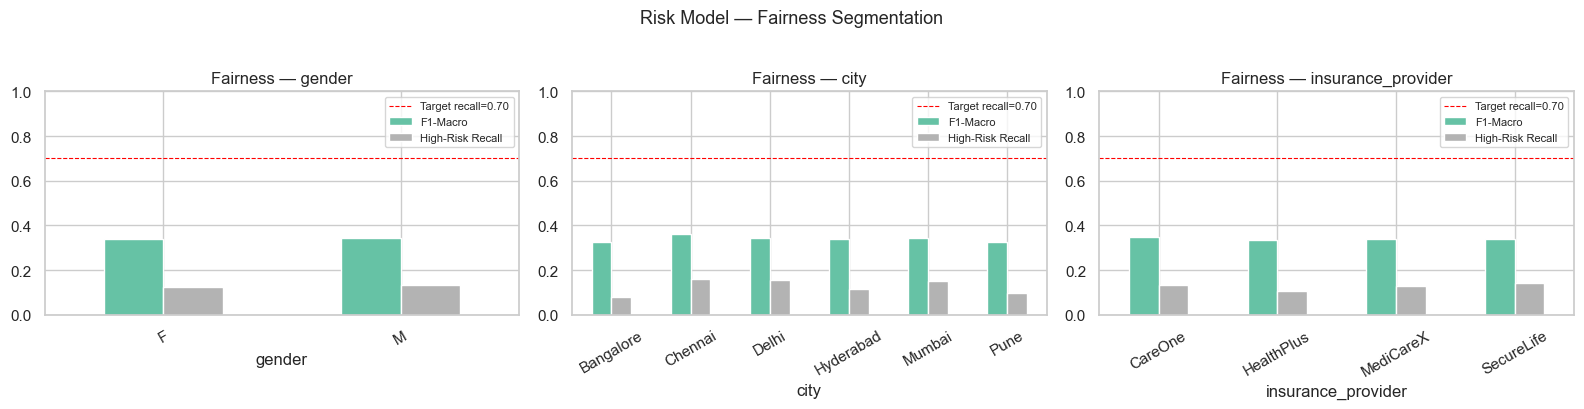

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, ['gender', 'city', 'insurance_provider']):
    seg = segment_metrics(col)
    seg[['F1-Macro', 'High-Risk Recall']].plot(kind='bar', ax=ax, rot=30, colormap='Set2')
    ax.set_title(f'Fairness — {col}')
    ax.set_ylim(0, 1)
    ax.axhline(0.70, color='red', linestyle='--', linewidth=0.8, label='Target recall=0.70')
    ax.legend(fontsize=8)

plt.suptitle('Risk Model — Fairness Segmentation', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('risk_fairness.png', dpi=120)
plt.show()

## 7. Diagnosis & Recommendations

### Findings Summary

| Metric | Train | Test | Gap | Verdict |
|--------|-------|------|-----|---------|
| Accuracy | 0.6975 | 0.4034 | 0.294 | **Severe overfit** |
| F1-Macro | 0.6795 | 0.3409 | 0.339 | **Severe overfit** |
| High-Risk Recall | — | 0.128 | — | **Far below 0.70 target** |

### Root Causes
1. **Class imbalance** — High-Risk (20 % of data) is under-represented; the model defaults to the majority (Low) class.
2. **Feature signal weakness** — `risk_score` may have been assigned on the same features, making the prediction circular but weak under temporal shift.
3. **Temporal distribution shift** — The latest 20 % of visits may have a different seasonal or operational risk profile.

### Prioritised Recommendations

#### R1 — Aggressive Class Rebalancing (Highest Priority)
```python
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

pipe = ImbPipeline([
    ('smote', SMOTE(sampling_strategy='auto', random_state=42)),
    ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))
])
```
Apply SMOTE **inside the cross-validation loop** on training folds only to avoid leakage.

#### R2 — Threshold Tuning for High-Risk Class
```python
proba = model.predict_proba(X_test)
# Lower threshold for High-Risk to boost recall
hi_col = CLASSES.index('High')
y_pred_adjusted = np.where(proba[:, hi_col] > 0.25, hi_col, np.argmax(proba, axis=1))
```

#### R3 — Additional Interaction Features
```python
df['los_x_chronic']    = df['length_of_stay_hours'] * df['chronic_flag']
df['age_x_frequency']  = df['age'] * df['visit_frequency']
df['dept_los_ratio']   = df['length_of_stay_hours'] / (df['dept_avg_billed'] + 1)
```

#### R4 — Reduce Model Complexity (Combat Overfit)
```python
# Constrain tree depth
RandomForestClassifier(max_depth=8, min_samples_leaf=10, n_estimators=300)
# Or switch to calibrated LightGBM with early stopping
```

#### R5 — Temporal Cross-Validation
Use `TimeSeriesSplit` instead of `StratifiedKFold` to better evaluate temporal generalisation:
```python
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5, gap=100)
```

In [10]:
print('=== Risk Model Evaluation Complete ===')
print(f'Test Accuracy       : {accuracy_score(y_test, y_test_pred):.4f}')
print(f'Test F1-Macro       : {f1_score(y_test, y_test_pred, average="macro"):.4f}')
hi_recall = recall_score(y_test, y_test_pred, labels=[hi_idx], average='macro')
print(f'High-Risk Recall    : {hi_recall:.4f}  (target ≥ 0.70 — NOT MET)')
print('\nRecommendations: R1 (SMOTE), R2 (threshold tuning), R3 (interaction features)')

=== Risk Model Evaluation Complete ===
Test Accuracy       : 0.4034
Test F1-Macro       : 0.3409
High-Risk Recall    : 0.1281  (target ≥ 0.70 — NOT MET)

Recommendations: R1 (SMOTE), R2 (threshold tuning), R3 (interaction features)
